# trade volume volatility forecasting using pytorch-forecasting base on btc-ohlc 

In [1]:
import pandas as pd
import numpy as np

# 1. 加载数据 (假设你的数据在 csv 中)
# 注意：你的 Timestamp 是纳秒级 (19位数字)，需要正确解析
df = pd.read_csv("OKX-HFT-BTC-USDT-2025-03.csv")
df['Datetime'] = pd.to_datetime(df['Timestamp'], unit='ns') 
df = df.sort_values('Datetime').reset_index(drop=True)

# ============================
# 2. 特征工程 (Feature Engineering)
# ============================

# A. 处理 Volume (成交量通常是幂律分布，必须取对数)
# 加上 1e-8 防止 log(0)
df['log_volume'] = np.log1p(df['Volume'])

# B. 构造 Target: Volume 的波动率 (Volatility)
# 定义波动率：这里以 "过去 10 分钟 log_volume 的滚动标准差" 为例
# 实际预测时，模型会根据历史输入，预测未来的这个指标
df['volatility_target'] = df['log_volume'].rolling(window=10).std()

# C. 价格特征 (不要直接用 Close，要用收益率)
df['log_return'] = np.log(df['Close'] / df['Close'].shift(1))
df['high_low_pct'] = (df['High'] - df['Low']) / df['Close'] # 烛台震幅

# D. 填充因计算滚动特征产生的 NaN
df = df.fillna(0)  # 或者 dropna()，取决于数据量

# ============================
# 3. 处理时间分段 (关键步骤)
# ============================

# A. 识别断点：如果两条数据间隔超过 2 分钟 (考虑到1min数据可能的微小延迟)，视为断开
df['time_diff'] = df['Datetime'].diff()
gap_threshold = pd.Timedelta(minutes=2)

# B. 生成 segment_id
df['segment_id'] = (df['time_diff'] > gap_threshold).cumsum()

# C. 生成 group_ids 所需的列
# 建议增加一个 symbol 列，即使你现在只有一个币种，方便未来扩展
df['symbol'] = "BTC" 
df['segment_id'] = df['segment_id'].astype(str) # 转换为字符串类别

# D. 重置每一段内的 time_idx
df['time_idx'] = df.groupby(['symbol', 'segment_id']).cumcount()

# ============================
# 4. 提取时间特征 (Time Covariates)
# ============================
df['minute_of_hour'] = df['Datetime'].dt.minute.astype(str).astype("category")
df['hour_of_day'] = df['Datetime'].dt.hour.astype(str).astype("category")
df['day_of_week'] = df['Datetime'].dt.dayofweek.astype(str).astype("category")

# 检查一下数据
print(df[['Datetime', 'segment_id', 'time_idx', 'log_volume', 'volatility_target']].head(10))
print(df.describe())

                 Datetime segment_id  time_idx  log_volume  volatility_target
0 2025-03-02 07:45:41.604          0         0    0.231297            0.00000
1 2025-03-02 07:46:41.604          0         1    1.708188            0.00000
2 2025-03-02 07:47:41.604          0         2    0.963105            0.00000
3 2025-03-02 07:48:41.604          0         3    1.230873            0.00000
4 2025-03-02 07:49:41.604          0         4    1.012348            0.00000
5 2025-03-02 07:50:41.604          0         5    0.885475            0.00000
6 2025-03-02 07:51:41.604          0         6    0.773895            0.00000
7 2025-03-02 07:52:41.604          0         7    1.063265            0.00000
8 2025-03-02 07:53:41.604          0         8    1.343528            0.00000
9 2025-03-02 07:54:41.604          0         9    1.221313            0.38926
                            Datetime     Timestamp          Open  \
count                          28802  2.880200e+04  28802.000000   
mean  

In [2]:
from pytorch_forecasting import TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer

max_encoder_length = 360
# 过滤掉长度不够的 segment (如果某一段只有 5 分钟，无法构建 60+10 的窗口，必须丢弃)
min_length_needed = max_encoder_length + 10
valid_segments = df.groupby('segment_id').size()
valid_segments = valid_segments[valid_segments >= min_length_needed].index
df_filtered = df[df['segment_id'].isin(valid_segments)]

# 设置 Dataset
dataset = TimeSeriesDataSet(
    df_filtered,
    time_idx="time_idx",
    target="volatility_target",  # 我们的预测目标是构造好的波动率指标
    
    # 关键：利用 symbol 和 segment_id 进行物理隔离
    group_ids=["symbol", "segment_id"],
    
    min_encoder_length=30,       # 允许最短看30分钟
    max_encoder_length=max_encoder_length,       # 最长看60分钟
    min_prediction_length=1,
    max_prediction_length=10,    # 预测未来10个点
    
    # 静态变量 (Static)
    static_categoricals=["symbol"], # segment_id 绝对不要放这里！
    
    # 时间相关的已知变量 (日期/时间)
    time_varying_known_categoricals=["minute_of_hour", "hour_of_day", "day_of_week"],
    time_varying_known_reals=["time_idx"],
    
    # 时间相关的未知变量 (即：只有过去了才知道的数据)
    # 这些特征会被 Encoder 用来学习模式
    time_varying_unknown_reals=[
        "volatility_target", # 目标本身也是输入之一 (自回归)
        "log_volume",        # 辅助特征：成交量大小
        "log_return",        # 辅助特征：价格涨跌幅
        "high_low_pct",      # 辅助特征：K线震幅
    ],
    
    # 归一化处理
    # 波动率通常大于0，且不同币种/时段差异大，使用 GroupNormalizer
    target_normalizer=GroupNormalizer(
        groups=["symbol", "segment_id"], transformation="softplus"
    ),
    
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)

# 生成 DataLoader
batch_size = 512
train_dataloader = dataset.to_dataloader(train=True, batch_size=batch_size, num_workers=4,persistent_workers=True,pin_memory=True)

d:\Software\miniconda3\envs\torch_env\lib\site-packages\pytorch_forecasting\models\base\_base_model.py:28: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


## 构建验证集 (Validation Set)

In [6]:
from pytorch_forecasting.data.encoders import NaNLabelEncoder

# 假设 df_filtered 是上一节处理好的完整数据
# 获取所有的 segment_id 列表
all_segments = df_filtered['segment_id'].unique()

# 划分训练集和验证集：例如保留最后 20% 的段作为验证集
train_len = int(len(all_segments) * 0.8)
train_segments = all_segments[:train_len]
val_segments = all_segments[train_len:]

# 切分 DataFrame
train_df = df_filtered[df_filtered['segment_id'].isin(train_segments)]
val_df = df_filtered[df_filtered['segment_id'].isin(val_segments)]

# 1. 创建训练数据集 (已在上一节定义，这里复用逻辑)
training = TimeSeriesDataSet(
    train_df,
    time_idx="time_idx",
    target="volatility_target",
    group_ids=["symbol", "segment_id"],
    min_encoder_length=30,
    max_encoder_length=max_encoder_length,
    min_prediction_length=1,
    max_prediction_length=10,
    static_categoricals=["symbol"],
    categorical_encoders={
        "segment_id": NaNLabelEncoder(add_nan=True)
    },
    time_varying_known_categoricals=["minute_of_hour", "hour_of_day", "day_of_week"],
    time_varying_known_reals=["time_idx"],
    time_varying_unknown_reals=[
        "volatility_target", "log_volume", "log_return", "high_low_pct"
    ],
    target_normalizer=GroupNormalizer(
        groups=["symbol", "segment_id"], transformation="softplus"
    ),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)

# 2. 创建验证数据集
# 注意：必须使用 from_dataset 方法，这样验证集会复用训练集的 Scaler 和 Encoder 配置，防止数据泄漏
validation = TimeSeriesDataSet.from_dataset(training, val_df, predict=True, stop_randomization=True)

# 3. 创建 DataLoaders
batch_size = 512
train_dataloader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=4,persistent_workers=True,pin_memory=True)
val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size * 10, num_workers=4,persistent_workers=True,pin_memory=True)

d:\Software\miniconda3\envs\torch_env\lib\site-packages\pytorch_forecasting\data\encoders.py:401: UserWarning: Found 6 unknown classes which were set to NaN
  warnings.warn(


## 寻找最佳学习率

In [4]:
# import lightning.pytorch as pl
# from lightning.pytorch.tuner import Tuner
# from pytorch_forecasting import TemporalFusionTransformer
# from pytorch_forecasting.metrics import QuantileLoss

# # 1. 初始化 Trainer
# # 注意：这里不需要 max_epochs，因为 LR Finder 只会跑很少的步数
# trainer = pl.Trainer(
#     accelerator="gpu",
#     devices=1,
#     precision="32",  # 开启混合精度，节省显存，速度更快
#     gradient_clip_val=0.1,  # 保持梯度裁剪，防止爆炸
# )

# # 2. 初始化模型 (给一个初始的 LR 即可，比如 0.03，反正会被覆盖)
# tft = TemporalFusionTransformer.from_dataset(
#     training,
#     learning_rate=0.03,
#     hidden_size=32,
#     attention_head_size=2,
#     dropout=0.2,
#     hidden_continuous_size=16,
#     loss=QuantileLoss(),
#     optimizer="ranger",
# )

# # 3. 初始化 Tuner 并运行 lr_find
# tuner = Tuner(trainer)

# print("🔍 开始寻找最佳学习率...")
# lr_finder = tuner.lr_find(
#     tft,
#     train_dataloaders=train_dataloader,
#     val_dataloaders=val_dataloader,
#     min_lr=1e-5,    # 最小尝试值
#     max_lr=1.0,     # 最大尝试值
#     num_training=100, # 运行多少个 Batch，通常 100 够了，数据量大可以设 200
# )

# # 4. 获取建议值
# suggested_lr = lr_finder.suggestion()
# print(f"🤖 系统建议的最佳学习率: {suggested_lr}")

# # 5. 绘制曲线图 (非常重要，建议人工确认)
# fig = lr_finder.plot(suggest=True)
# fig.show()

## 定义并训练 Temporal Fusion Transformer (TFT)

In [7]:
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor
from lightning.pytorch.loggers import TensorBoardLogger
from pytorch_forecasting import TemporalFusionTransformer
from pytorch_forecasting.metrics import QuantileLoss

# 1. 配置回调函数
# EarlyStopping: 如果验证集 Loss 在 5 个 epoch 内没有下降，停止训练
early_stop_callback = EarlyStopping(
    monitor="val_loss", min_delta=1e-4, patience=5, verbose=False, mode="min"
)
lr_logger = LearningRateMonitor()  # 记录学习率变化

# 2. 配置 Trainer
trainer = pl.Trainer(
    max_epochs=100,             # 金融数据通常不需要几百个 epoch，容易过拟合
    accelerator="gpu",        # 自动检测 GPU/MPS (Mac) / CPU
    devices=1,
    precision="32",
    gradient_clip_val=0.1,     # 梯度裁剪，防止梯度爆炸 (这对 LSTM/TFT 很重要)
    callbacks=[lr_logger, early_stop_callback],
    enable_model_summary=True,
)

# 3. 初始化模型
tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.01,        # 初始学习率，可以通过 lr_finder 优化
    hidden_size=32,            # 隐藏层大小，金融数据太大会过拟合，建议 16-64
    attention_head_size=2,     # 注意力头数
    dropout=0.2,               # Dropout 设高一点 (0.1-0.3) 增加鲁棒性
    hidden_continuous_size=16, 
    loss=QuantileLoss(),       # 默认分位数损失，适合预测波动范围
    optimizer="ranger",        # Ranger 优化器在时序任务表现通常优于 Adam
    reduce_on_plateau_patience=3, # 学习率自动衰减
)

print(f"模型参数量: {tft.size() / 1e3:.1f}k")

# 4. 开始训练
trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
d:\Software\miniconda3\envs\torch_env\lib\site-packages\lightning\pytorch\utilities\parsing.py:210: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
d:\Software\miniconda3\envs\torch_env\lib\site-packages\lightning\pytorch\utilities\parsing.py:210: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                               | Type                            | Params | Mode 
---------

模型参数量: 78.1k
Epoch 99: 100%|██████████| 56/56 [02:07<00:00,  0.44it/s, v_num=26, train_loss_step=0.0891, val_loss=0.0845, train_loss_epoch=0.0884]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 99: 100%|██████████| 56/56 [02:07<00:00,  0.44it/s, v_num=26, train_loss_step=0.0891, val_loss=0.0845, train_loss_epoch=0.0884]


## 模型评估与 Baseline 对比

In [9]:
from pytorch_forecasting import Baseline
from pytorch_forecasting.metrics import MAE

# ================= 1. Baseline 部分 =================
baseline_predictions = Baseline().predict(val_dataloader, return_y=True)

# 【修正点】：baseline_predictions.y 是一个 tuple (target, weight)
# 我们需要取 y[0] 才是真正的数值 tensor
baseline_mae = MAE()(
    baseline_predictions.output.cpu(), 
    baseline_predictions.y[0].cpu() 
)

# ================= 2. TFT 模型部分 =================
best_model_path = trainer.checkpoint_callback.best_model_path
best_tft = TemporalFusionTransformer.load_from_checkpoint(best_model_path)
# 强制在 CPU 上预测，这样 output 自动在 CPU 上
tft_predictions = best_tft.predict(
    val_dataloader, 
    return_y=True, 
    trainer_kwargs=dict(accelerator="cpu") 
)

# 【修正点】：同样，这里也要取 y[0]
# 因为上面的 predict 强制用了 CPU，所以这里的 tensor 应该已经在 CPU 上了，不需要再 .cpu()
# 但为了保险，写上也没问题，或者直接传 tft_predictions.y[0]
tft_mae = MAE()(
    tft_predictions.output, 
    tft_predictions.y[0]
)

# ================= 3. 输出结果 =================
print(f"Baseline MAE: {baseline_mae.item():.4f}")
print(f"TFT Model MAE: {tft_mae.item():.4f}")

if tft_mae < baseline_mae:
    print("🎉 模型表现优于简单的历史重复基准！")
else:
    print("⚠️ 模型表现未超过基准，可能需要调整特征或超参数。")

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
d:\Software\miniconda3\envs\torch_env\lib\site-packages\lightning\pytorch\utilities\parsing.py:210: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
d:\Software\miniconda3\envs\torch_env\lib\site-packages\lightning\pytorch\utilities\parsing.py:210: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project

Baseline MAE: 0.1315
TFT Model MAE: 0.1853
⚠️ 模型表现未超过基准，可能需要调整特征或超参数。


## 可视化分析

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


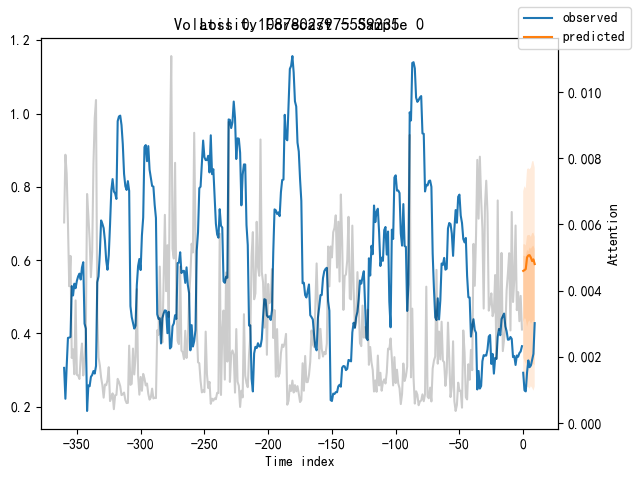

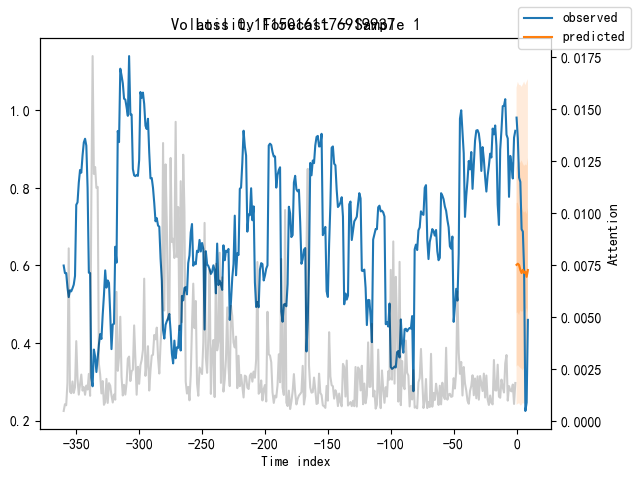

Epoch 1:   0%|          | 0/56 [4:43:23<?, ?it/s, v_num=25, train_loss_step=0.237, val_loss=0.223, train_loss_epoch=0.235]


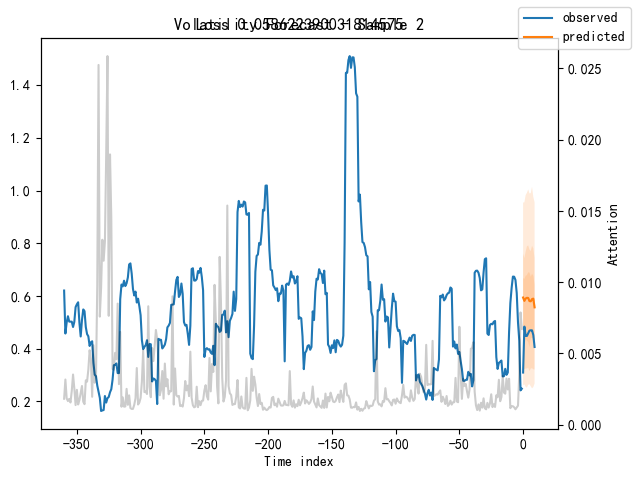

In [10]:
import matplotlib.pyplot as plt

# 获取原始预测结果（包含所有分位数）
raw_predictions = best_tft.predict(
    val_dataloader, 
    mode="raw", 
    return_x=True,
    # n_samples=100 # 随机抽样多少个例子来画图
)

# 绘制前 3 个样本的预测
# 这里的 idx 是 batch 中的索引
for idx in range(3):
    fig = best_tft.plot_prediction(
        raw_predictions.x, 
        raw_predictions.output, 
        idx=idx, 
        add_loss_to_title=True
    )
    plt.title(f"Volatility Forecast - Sample {idx}")
    plt.show()

## 变量重要性分析 (Feature Importance)

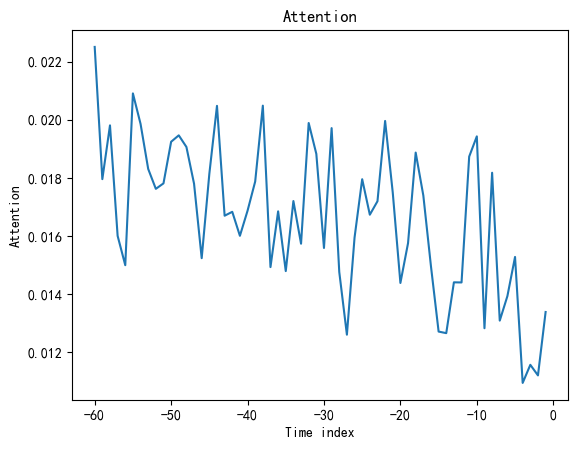

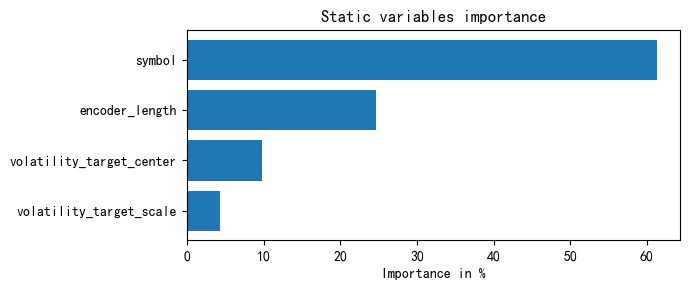

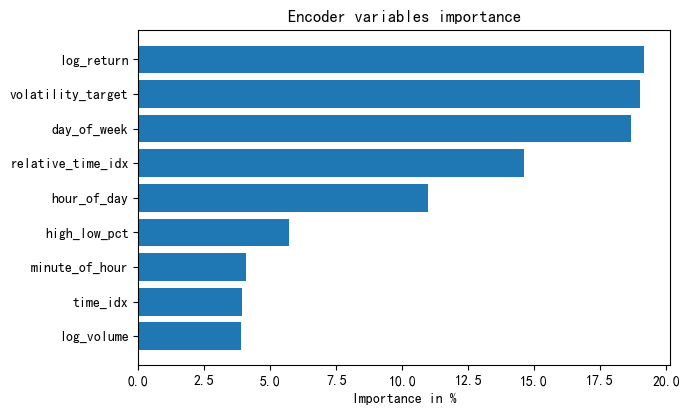

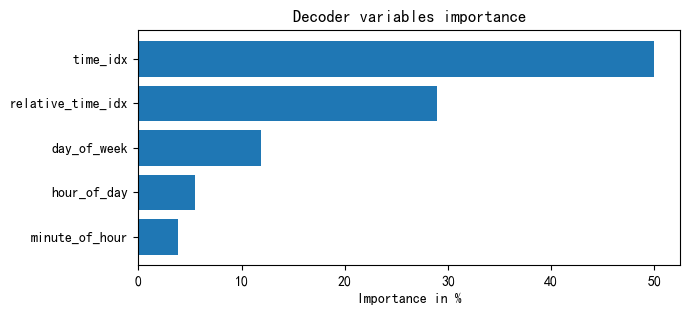

In [16]:
# 计算并绘制变量重要性
interpretation = best_tft.interpret_output(raw_predictions.output, reduction="sum")
best_tft.plot_interpretation(interpretation)
plt.show()